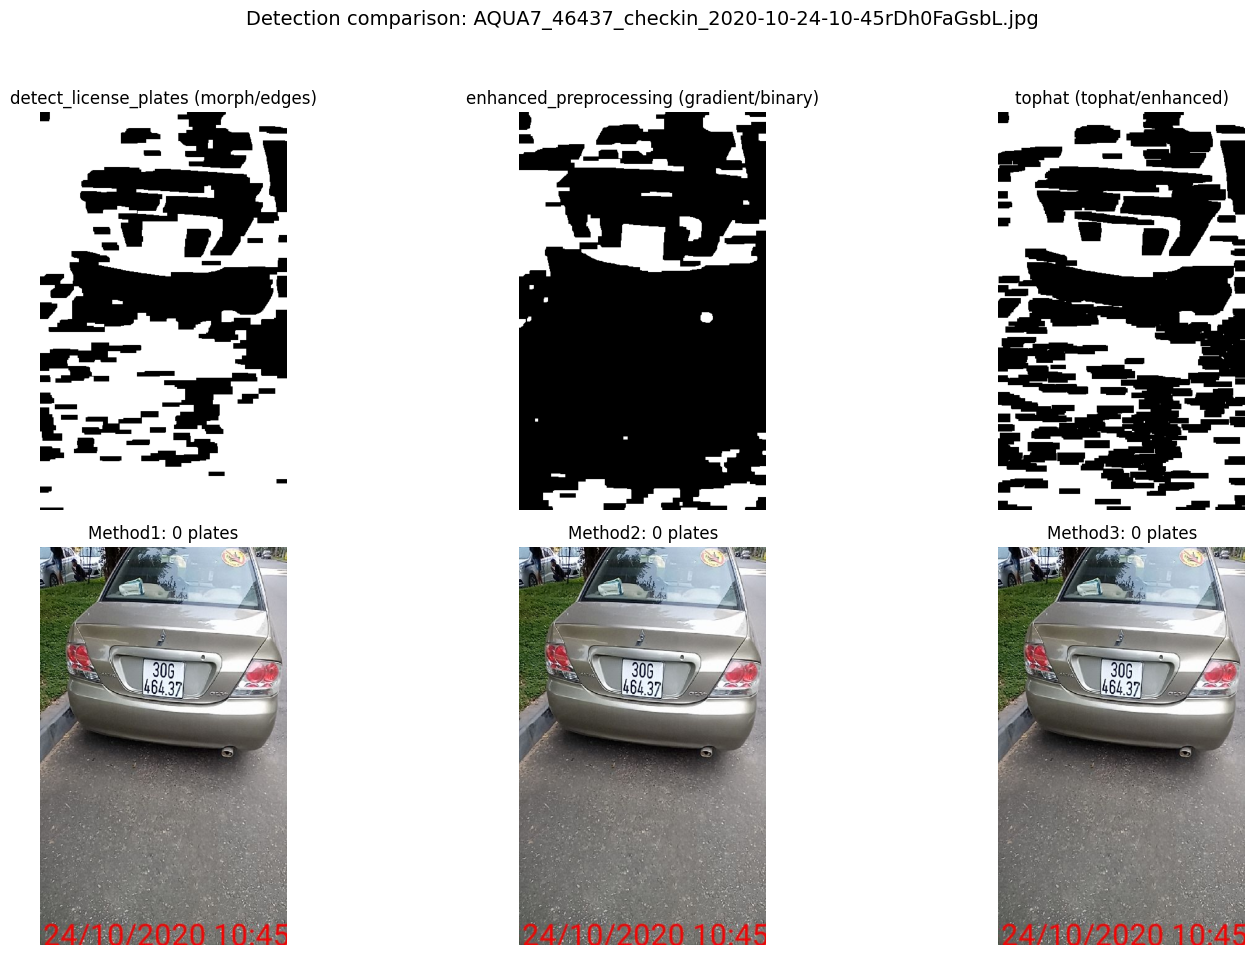

=== Summary ===
Method1 detect_license_plates:  0 plates. Rejected: {'area': 5, 'aspect': 0, 'solidity': 1, 'margin': 1}
Method2 enhanced_preprocessing: 0 plates. Rejected: {'area': 19, 'aspect': 5, 'solidity': 0, 'margin': 2}
Method3 tophat: 0 plates. Rejected: {'area': 39, 'aspect': 0, 'solidity': 1, 'margin': 0}


In [6]:
# Paste this cell into your notebook and run
import sys
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Ensure project root is on path (works when notebook is in tests/)
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.lp_detector import (
    detect_license_plates,
    detect_with_enhanced_preprocessing,
    detect_with_tophat
)

# ---------- Config ----------
# Use relative path from project root (or set an absolute path)
image_rel = "/Users/khoado/code/license-plate-recognition/data/test_images/CarTGMT/AQUA7_46437_checkin_2020-10-24-10-45rDh0FaGsbL.jpg"
image_path = project_root / image_rel

# ---------- Load image ----------
img = cv2.imread(str(image_path))
if img is None:
    raise FileNotFoundError(f"Cannot load image: {image_path}")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ---------- Run detectors (debug=True to get intermediate images) ----------
plates1, debug1 = detect_license_plates(gray, mode="car_square", debug=True)
plates2, debug2 = detect_with_enhanced_preprocessing(gray, mode="car_square", debug=True)
plates3, debug3 = detect_with_tophat(gray, mode="car_square", debug=True)

# ---------- Helpers ----------
def draw_plates_bgr(bgr_img, plates, color=(0,255,0), thickness=2):
    out = bgr_img.copy()
    for (x,y,w,h) in plates:
        cv2.rectangle(out, (x,y), (x+w, y+h), color, thickness)
    return out

def to_display(img):
    # Convert BGR->RGB for color images; for single-channel, return as-is
    if img is None:
        return None
    if len(img.shape) == 3 and img.shape[2] == 3:
        return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

def safe_get_debug(debug_dict, keys):
    for k in keys:
        v = debug_dict.get(k)
        if v is not None:
            return v
    return None

# ---------- Prepare images for visualization ----------
# Intermediate: method1 uses 'edges'/'morph', method2 uses 'gradient'/'morph'/'enhanced', method3 uses 'tophat'/'enhanced'
int1 = safe_get_debug(debug1, ("morph", "edges"))
int2 = safe_get_debug(debug2, ("morph", "gradient", "enhanced", "binary"))
int3 = safe_get_debug(debug3, ("morph", "enhanced", "tophat", "binary"))

# Result images (annotated)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
res1 = to_display(draw_plates_bgr(img, plates1, color=(0,255,0)))
res2 = to_display(draw_plates_bgr(img, plates2, color=(255,165,0)))
res3 = to_display(draw_plates_bgr(img, plates3, color=(255,0,255)))

# Resize for display if very large (adjust max dimension)
def maybe_resize(img, max_dim=960):
    if img is None:
        return None
    h, w = img.shape[:2]
    scale = min(1.0, max_dim / max(h, w))
    if scale < 1.0:
        return cv2.resize(img, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_AREA)
    return img

int1 = maybe_resize(int1)
int2 = maybe_resize(int2)
int3 = maybe_resize(int3)
res1 = maybe_resize(res1)
res2 = maybe_resize(res2)
res3 = maybe_resize(res3)

# ---------- Plot ----------
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(f"Detection comparison: {image_path.name}", fontsize=14)

# Top row: intermediate steps (grayscale)
for ax, im, title in zip(axes[0], [int1, int2, int3],
                         ["detect_license_plates (morph/edges)",
                          "enhanced_preprocessing (gradient/binary)",
                          "tophat (tophat/enhanced)"]):
    if im is None:
        ax.text(0.5, 0.5, "no debug image", ha='center', va='center')
        ax.set_title(title)
        ax.axis("off")
        continue
    if len(im.shape) == 2:
        ax.imshow(im, cmap="gray")
    else:
        ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")

# Bottom row: results with bounding boxes
axes[1,0].imshow(res1)
axes[1,0].set_title(f"Method1: {len(plates1)} plates")
axes[1,0].axis("off")

axes[1,1].imshow(res2)
axes[1,1].set_title(f"Method2: {len(plates2)} plates")
axes[1,1].axis("off")

axes[1,2].imshow(res3)
axes[1,2].set_title(f"Method3: {len(plates3)} plates")
axes[1,2].axis("off")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# ---------- Optionally, show cropped plate images ----------
def show_crops(img_bgr, plates, title_prefix="crop"):
    crops = []
    for i, (x,y,w,h) in enumerate(plates):
        crop = img_bgr[y:y+h, x:x+w]
        crops.append((i, crop))
    if not crops:
        print(f"No crops for {title_prefix}")
        return
    cols = min(4, len(crops))
    rows = (len(crops) + cols - 1) // cols
    fig, axs = plt.subplots(rows, cols, figsize=(cols*3, rows*2.5))
    axs = np.array(axs).reshape(-1)
    for ax in axs:
        ax.axis("off")
    for (i, crop), ax in zip(crops, axs):
        ax.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{title_prefix} #{i}")
    plt.tight_layout()
    plt.show()

# Uncomment to display crops for each method
# show_crops(img, plates1, "method1")
# show_crops(img, plates2, "method2")
# show_crops(img, plates3, "method3")

# ---------- Print debug summaries ----------
print("=== Summary ===")
print("Method1 detect_license_plates: ", len(plates1), "plates. Rejected:", debug1.get("rejected", {}))
print("Method2 enhanced_preprocessing:", len(plates2), "plates. Rejected:", debug2.get("rejected", {}))
print("Method3 tophat:", len(plates3), "plates. Rejected:", debug3.get("rejected", {}))